In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (change to pd.read_csv if you downloaded a CSV file)
df = pd.read_excel('../data/Online_Retail.xlsx')

# Look at the first 5 rows to ensure it loaded correctly
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# See how many rows have empty spaces
print(df.isnull().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [3]:
# Drop rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])


In [4]:
# Convert CustomerID from a float (12345.0) to an integer or string category
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# Ensure InvoiceDate is recognized as a true date-time object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [5]:
# Create a new column to calculate total spend per transaction line
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Separate normal purchases from cancellations into two dataframes
df_cancelled = df[df['Quantity'] < 0]
df_cleaned = df[df['Quantity'] >= 0]

print(f"Cleaned dataset has {df_cleaned.shape[0]} rows remaining.")


Cleaned dataset has 397924 rows remaining.


In [6]:
#Performing the EDA (Exploratory Data Analysis) on the cleaned dataset

C:\Users\rajan\AppData\Local\Temp\ipykernel_14376\2424801323.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour
C:\Users\rajan\AppData\Local\Temp\ipykernel_14376\2424801323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Hour', palette='viridis')


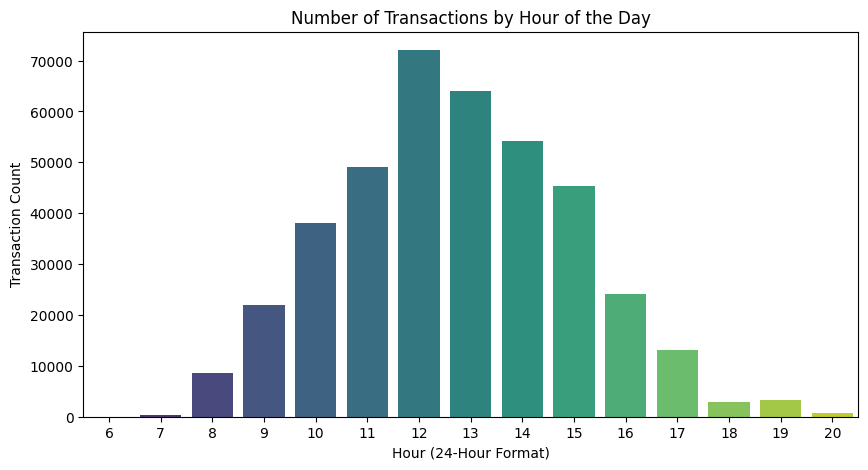

In [7]:
# Extract the hour from the InvoiceDate
df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour

# Plot a bar chart of transactions by hour
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x='Hour', palette='viridis')
plt.title('Number of Transactions by Hour of the Day')
plt.xlabel('Hour (24-Hour Format)')
plt.ylabel('Transaction Count')
plt.show()


In [8]:
# Calculate total revenue generated by each unique product
product_revenue = df_cleaned.groupby('Description')['TotalSpend'].sum().sort_values(ascending=False).reset_index()

# Calculate cumulative percentage of revenue
product_revenue['Cumulative_Revenue_Pct'] = product_revenue['TotalSpend'].cumsum() / product_revenue['TotalSpend'].sum()

# Find out what % of items make up 80% of revenue
total_unique_products = len(product_revenue)
products_driving_80_pct = product_revenue[product_revenue['Cumulative_Revenue_Pct'] <= 0.80].shape[0]
percentage_of_inventory = (products_driving_80_pct / total_unique_products) * 100

print(f"Just {percentage_of_inventory:.2%}% of products generate 80% of the company's total revenue!")


Just 2089.24%% of products generate 80% of the company's total revenue!


In [10]:
# Customer RFM Segmentation

In [11]:
# Use the maximum date in the dataset as our reference point for "today"
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID to calculate Recency, Frequency, and Monetary values
rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                  # Frequency: Unique orders placed
    'TotalSpend': 'sum'                                      # Monetary: Total capital spent
})

# Rename the columns clearly
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


C:\Users\rajan\AppData\Local\Temp\ipykernel_14376\3621308026.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', palette='Set2')


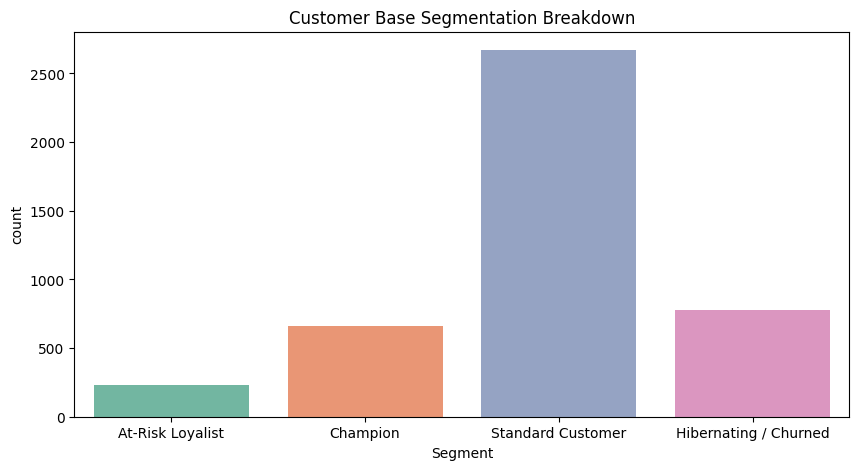

In [12]:
# Define a simple classification function
def segment_customer(row):
    if row['Recency'] <= 30 and row['Frequency'] > 5:
        return 'Champion'
    elif row['Recency'] > 90 and row['Monetary'] > 1000:
        return 'At-Risk Loyalist'
    elif row['Recency'] > 180:
        return 'Hibernating / Churned'
    else:
        return 'Standard Customer'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Plot your customer segments
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, x='Segment', palette='Set2')
plt.title('Customer Base Segmentation Breakdown')
plt.show()
